# **Methodological Reuse**
This analysis adapts techniques from my previous music genre classification project. In the music project, high dimensional audio features were standardized and reduced using Principal Component Analysis (PCA), followed by two dimensional visualization using PCA and t-SNE. The same workflow was transferred to this market-segmentation problem. Instead of audio features, this analysis uses education-AI adoption indicators, including student AI usage, teacher AI usage, school adoption rates, internet penetration, education index, and policy support. PCA was used to reduce dimensionality and identify underlying patterns in the data, while t-SNE was used for lower dimensional visualization. Unlike the music project, which used supervised classification in addition to unsupervised learning, this project applies unsupervised clustering (K-Means and Gaussian Mixture Models) to identify candidate market segments for the Senpai educational AI platform.

https://www.kaggle.com/datasets/abidhussai512/global-ai-in-education-dataset-20152026/data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

from pathlib import Path
import kagglehub

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

Setting seed to ensure the code ouputs the same results everytime.

In [3]:
# =====================================================
# SET SEED
# =====================================================
n_num = 10705642

random.seed(n_num)
np.random.seed(n_num)

In [27]:
# =====================================================
# LOAD DATA
# =====================================================
print("\n------- LOAD DATA -------\n")

path = kagglehub.dataset_download(
    "abidhussai512/global-ai-in-education-dataset-20152026"
)

csv_file = next(Path(path).rglob("*.csv"))

df = pd.read_csv(csv_file)

print("Shape:", df.shape)
df.head()


------- LOAD DATA -------

Using Colab cache for faster access to the 'global-ai-in-education-dataset-20152026' dataset.
Shape: (1360, 16)


,year,month,country,region,student_ai_usage_pct,teacher_ai_usage_pct,schools_ai_adoption_pct,avg_daily_ai_usage_min,top_ai_tool,internet_penetration_pct,education_index,government_ai_policy,urban_ai_usage_pct,rural_ai_usage_pct,ai_in_curriculum,gender_gap_ai_usage_pct
0,2015,1,United States,North America,1,2,1,19,Google Gemini,90,0.90,NaN,1,0,Yes,6
1,2015,1,United Kingdom,Europe,4,1,5,11,Google Gemini,92,0.91,Draft,7,0,Yes,5
2,2015,1,China,Asia,6,5,4,7,ChatGPT,70,0.75,Active,8,1,No,7
3,2015,1,India,Asia,7,5,0,59,Microsoft Copilot,50,0.64,NaN,10,0,Yes,7
4,2015,1,Germany,Europe,9,7,6,29,Khanmigo,93,0.94,Active,13,0,Yes,1


In [5]:
# =====================================================
# DATA CLEANING
# =====================================================

print("\n------- DATA CLEANING -------\n")

print(df.dtypes)

numeric_cols = df.select_dtypes(
    include=["float64", "int64"]
).columns

imputer = SimpleImputer(strategy="median")

df[numeric_cols] = imputer.fit_transform(
    df[numeric_cols]
)



------- DATA CLEANING -------

year                          int64
month                         int64
country                      object
region                       object
student_ai_usage_pct          int64
teacher_ai_usage_pct          int64
schools_ai_adoption_pct       int64
avg_daily_ai_usage_min        int64
top_ai_tool                  object
internet_penetration_pct      int64
education_index             float64
government_ai_policy         object
urban_ai_usage_pct            int64
rural_ai_usage_pct            int64
ai_in_curriculum             object
gender_gap_ai_usage_pct       int64
dtype: object


In [6]:
# =====================================================
# ENCODE CATEGORICAL VARIABLES
# =====================================================

df["government_ai_policy"] = (
    df["government_ai_policy"]
    .fillna("None")
    .map({
        "None": 0,
        "Draft": 1,
        "Active": 2
    })
)

df["ai_in_curriculum"] = (
    df["ai_in_curriculum"]
    .map({
        "No": 0,
        "Yes": 1
    })
)

In [7]:
# =====================================================
# FEATURE ENGINEERING
# =====================================================

print("\n------- FEATURE ENGINEERING -------\n")

df["urban_rural_gap"] = (
    df["urban_ai_usage_pct"]
    - df["rural_ai_usage_pct"]
)

df["student_teacher_gap"] = (
    df["student_ai_usage_pct"]
    - df["teacher_ai_usage_pct"]
)

df["adoption_efficiency"] = (
    df["schools_ai_adoption_pct"]
    /
    (df["internet_penetration_pct"] + 1)
)

df["policy_curriculum_alignment"] = (
    df["government_ai_policy"]
    *
    df["ai_in_curriculum"]
)



------- FEATURE ENGINEERING -------



In [26]:
# =====================================================
# AGGREGATE DATASET TO COUNTRY LEVEL
# =====================================================

country_df = (
    df.groupby("country")
    .agg({
        "student_ai_usage_pct":"mean",
        "teacher_ai_usage_pct":"mean",
        "schools_ai_adoption_pct":"mean",
        "avg_daily_ai_usage_min":"mean",
        "internet_penetration_pct":"mean",
        "education_index":"mean",
        "government_ai_policy":"mean",
        "urban_ai_usage_pct":"mean",
        "rural_ai_usage_pct":"mean",
        "ai_in_curriculum":"mean",
        "gender_gap_ai_usage_pct":"mean",
        "urban_rural_gap":"mean",
        "student_teacher_gap":"mean",
        "adoption_efficiency":"mean",
        "policy_curriculum_alignment":"mean"
    })
    .reset_index()
)

print("\nCountry Level Data:")
print(country_df.shape)
country_df.head (10)


Country Level Data:
(10, 16)


,country,student_ai_usage_pct,teacher_ai_usage_pct,schools_ai_adoption_pct,avg_daily_ai_usage_min,internet_penetration_pct,education_index,government_ai_policy,urban_ai_usage_pct,rural_ai_usage_pct,ai_in_curriculum,gender_gap_ai_usage_pct,urban_rural_gap,student_teacher_gap,adoption_efficiency,policy_curriculum_alignment
0,Australia,31.007353,29.779412,29.632353,34.433824,96.0,0.93,0.970588,33.602941,21.720588,0.551471,5.169118,11.882353,1.227941,0.305488,0.544118
1,Brazil,30.602941,29.808824,29.411765,30.338235,75.0,0.70,1.095588,33.176471,21.323529,0.536765,5.095588,11.852941,0.794118,0.386997,0.602941
2,Canada,31.073529,29.941176,29.529412,35.463235,94.0,0.92,1.022059,33.544118,21.316176,0.419118,5.676471,12.227941,1.132353,0.310836,0.419118
3,China,30.897059,29.779412,28.955882,33.088235,70.0,0.75,0.933824,33.514706,21.352941,0.463235,5.764706,12.161765,1.117647,0.407829,0.419118
4,Germany,30.757353,30.227941,29.838235,32.080882,93.0,0.94,0.963235,33.463235,21.338235,0.536765,5.286765,12.125000,0.529412,0.317428,0.507353
5,India,31.000000,29.919118,29.147059,32.992647,50.0,0.64,1.007353,33.477941,21.911765,0.536765,5.514706,11.566176,1.080882,0.571511,0.514706
6,Nigeria,30.882353,29.580882,29.500000,33.661765,42.0,0.52,0.977941,33.566176,21.485294,0.470588,5.051471,12.080882,1.301471,0.686047,0.500000
7,Pakistan,31.029412,30.235294,29.654412,33.176471,45.0,0.55,1.154412,33.750000,21.507353,0.522059,5.727941,12.242647,0.794118,0.644661,0.610294
8,United Kingdom,31.007353,29.838235,29.213235,32.816176,92.0,0.91,1.022059,33.426471,21.742647,0.492647,5.176471,11.683824,1.169118,0.314121,0.470588
9,United States,31.610294,29.963235,29.213235,30.183824,90.0,0.90,1.095588,34.095588,22.308824,0.522059,5.661765,11.786765,1.647059,0.321025,0.602941


In [9]:
# =====================================================
# FEATURES
# =====================================================

features = [

    "student_ai_usage_pct",
    "teacher_ai_usage_pct",
    "schools_ai_adoption_pct",
    "avg_daily_ai_usage_min",

    "internet_penetration_pct",
    "education_index",

    "government_ai_policy",
    "ai_in_curriculum",

    "urban_ai_usage_pct",
    "rural_ai_usage_pct",

    "gender_gap_ai_usage_pct",

    "urban_rural_gap",
    "student_teacher_gap",

    "adoption_efficiency",
    "policy_curriculum_alignment"
]

X = country_df[features]

In [10]:
# =====================================================
# STANDARDIZATION
# =====================================================

print("\n------- SCALING -------\n")

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


------- SCALING -------



In [23]:
# =====================================================
# PCA
# =====================================================

print("\n------- PCA -------\n")

pca_full = PCA(
    n_components=0.95
)

X_pca = pca_full.fit_transform(
    X_scaled
)

loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f"PC{i+1}" for i in range(pca_full.n_components_)],
    index=features
)


print(loadings.round(3))

print(
    "PCA Components:",
    X_pca.shape[1]
)

print(
    "Variance Explained:",
    round(
        pca_full.explained_variance_ratio_.sum(),
        4
    )
)


------- PCA -------

                               PC1    PC2    PC3    PC4    PC5    PC6
student_ai_usage_pct         0.444  0.101 -0.145  0.191  0.129 -0.016
teacher_ai_usage_pct         0.049 -0.137  0.296  0.465 -0.213 -0.350
schools_ai_adoption_pct     -0.173 -0.111  0.316  0.261  0.598  0.004
avg_daily_ai_usage_min      -0.223  0.206 -0.243  0.180  0.398 -0.337
internet_penetration_pct     0.100  0.417  0.356  0.038  0.027  0.168
education_index              0.122  0.436  0.325  0.068  0.021 -0.031
government_ai_policy         0.203 -0.336  0.098  0.194 -0.114  0.496
ai_in_curriculum             0.146 -0.270  0.374 -0.191  0.082 -0.415
urban_ai_usage_pct           0.385 -0.012 -0.140  0.304  0.262 -0.048
rural_ai_usage_pct           0.469 -0.017 -0.039 -0.129  0.100 -0.257
gender_gap_ai_usage_pct      0.153  0.038 -0.208  0.457 -0.453 -0.186
urban_rural_gap             -0.253  0.011 -0.087  0.478  0.126  0.301
student_teacher_gap          0.342  0.174 -0.315 -0.141  0.247  0.21

PCA reduced the original 15 variables to 6 principal components while retaining 95.4% of total variance. The first two principal components explained 49.0% of total variance and were used for visualization. PC1 primarily captured overall AI adoption intensity, while PC2 reflected infrastructure and educational readiness.


In [24]:
# =====================================================
# 2D PCA FOR VISUALIZATION
# =====================================================

pca2 = PCA(
    n_components=2
)

X_pca2 = pca2.fit_transform(
    X_scaled
)

print(
    "2D Variance:",
    round(
        pca2.explained_variance_ratio_.sum(),
        4
    )
)


2D Variance: 0.4904



------- ELBOW -------



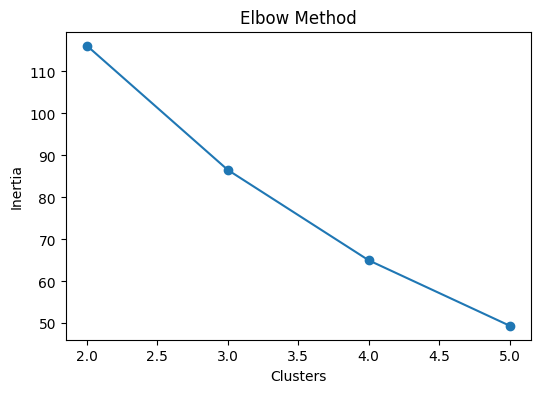

In [13]:
# =====================================================
# ELBOW METHOD
# =====================================================

print("\n------- ELBOW -------\n")

inertia = []

for k in range(2,6):

    km = KMeans(
        n_clusters=k,
        random_state=n_num,
        n_init=20
    )

    km.fit(X_scaled)

    inertia.append(
        km.inertia_
    )

plt.figure(figsize=(6,4))

plt.plot(
    range(2,6),
    inertia,
    marker="o"
)

plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [14]:
# =====================================================
# SILHOUETTE SCORES
# =====================================================

print("\n------- SILHOUETTE -------\n")

for k in range(2,6):

    km = KMeans(
        n_clusters=k,
        random_state=n_num,
        n_init=20
    )

    labels = km.fit_predict(
        X_scaled
    )

    score = silhouette_score(
        X_scaled,
        labels
    )

    print(
        f"K={k}: {score:.4f}"
    )



------- SILHOUETTE -------

K=2: 0.2176
K=3: 0.1135
K=4: 0.1220
K=5: 0.1041


In [15]:
# =====================================================
# FINAL KMEANS
# =====================================================

kmeans = KMeans(
    n_clusters=3,
    random_state=n_num,
    n_init=20
)

clusters = kmeans.fit_predict(
    X_scaled
)

country_df["cluster"] = clusters


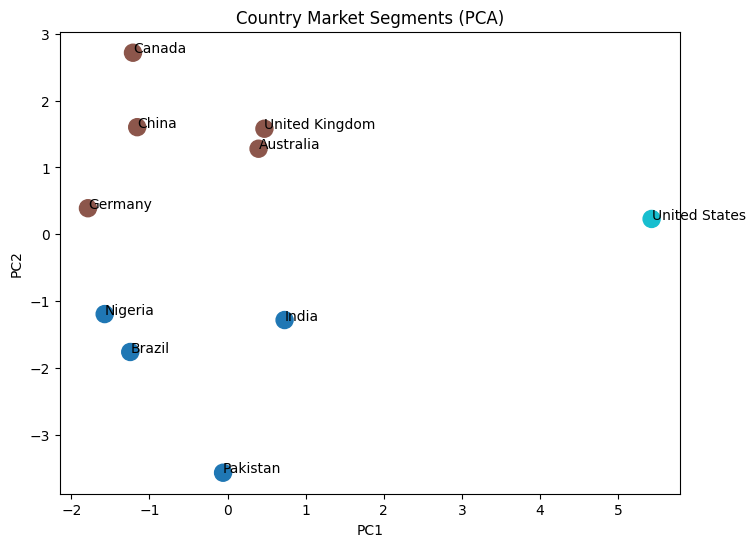

In [16]:
# =====================================================
# PCA VISUALIZATION
# =====================================================

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca2[:,0],
    X_pca2[:,1],
    c=clusters,
    cmap="tab10",
    s=150
)

for i, country in enumerate(country_df["country"]):

    plt.annotate(
        country,
        (
            X_pca2[i,0],
            X_pca2[i,1]
        )
    )

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "Country Market Segments (PCA)"
)

plt.show()


------- TSNE -------



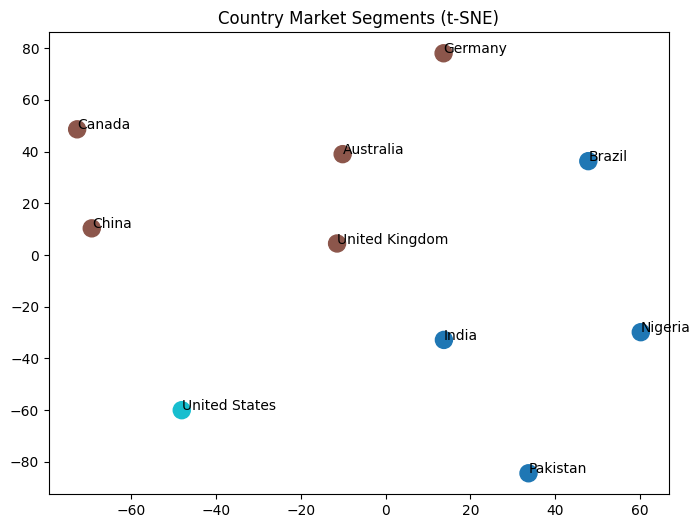

In [17]:
# =====================================================
# TSNE
# =====================================================

print("\n------- TSNE -------\n")

tsne = TSNE(
    n_components=2,
    perplexity=5,
    init="pca",
    random_state=n_num
)

X_tsne = tsne.fit_transform(
    X_scaled
)

plt.figure(figsize=(8,6))

plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=clusters,
    cmap="tab10",
    s=150
)

for i, country in enumerate(country_df["country"]):

    plt.annotate(
        country,
        (
            X_tsne[i,0],
            X_tsne[i,1]
        )
    )

plt.title(
    "Country Market Segments (t-SNE)"
)

plt.show()

In [18]:
# =====================================================
# GAUSSIAN MIXTURE
# =====================================================

print("\n------- GMM -------\n")

gmm = GaussianMixture(
    n_components=3,
    random_state=n_num
)

gmm_labels = gmm.fit_predict(
    X_scaled
)

gmm_score = silhouette_score(
    X_scaled,
    gmm_labels
)

kmeans_score = silhouette_score(
    X_scaled,
    clusters
)

print(
    "KMeans Score:",
    round(kmeans_score,4)
)

print(
    "GMM Score:",
    round(gmm_score,4)
)


------- GMM -------

KMeans Score: 0.1135
GMM Score: 0.0132


In [19]:
# =====================================================
# CLUSTER PROFILES
# =====================================================

print("\n------- CLUSTER PROFILES -------\n")

profiles = (
    country_df
    .groupby("cluster")[features]
    .mean()
    .round(2)
)

print(profiles)



------- CLUSTER PROFILES -------

         student_ai_usage_pct  teacher_ai_usage_pct  schools_ai_adoption_pct  \
cluster                                                                        
0                       30.88                 29.89                    29.43   
1                       30.95                 29.91                    29.43   
2                       31.61                 29.96                    29.21   

         avg_daily_ai_usage_min  internet_penetration_pct  education_index  \
cluster                                                                      
0                         32.54                      53.0             0.60   
1                         33.58                      89.0             0.89   
2                         30.18                      90.0             0.90   

         government_ai_policy  ai_in_curriculum  urban_ai_usage_pct  \
cluster                                                               
0                        1.06  

In [20]:
# =====================================================
# COUNTRIES IN EACH SEGMENT
# =====================================================

print("\n------- SEGMENT MEMBERS -------\n")

for c in sorted(
    country_df["cluster"].unique()
):

    print(f"\nCluster {c}")

    print(
        country_df.loc[
            country_df["cluster"] == c,
            "country"
        ].tolist()
    )



------- SEGMENT MEMBERS -------


Cluster 0
['Brazil', 'India', 'Nigeria', 'Pakistan']

Cluster 1
['Australia', 'Canada', 'China', 'Germany', 'United Kingdom']

Cluster 2
['United States']


The clustering analysis produced relatively modest separation between groups (K-Means silhouette score = 0.1135), suggesting that the countries are broadly similar in their AI adoption levels. The strongest differences between clusters appear to be infrastructure readiness and educational development rather than AI adoption itself.

# **Segment 1: Emerging Growth Markets**

**Countries**
- Brazil
- India
- Nigeria
- Pakistan


**Key Characteristics**

- Lowest internet penetration (53%)
- Lowest education index (0.60)
- Similar student and teacher AI usage compared to other segments
- Higher adoption efficiency score


**Interpretation**

These countries show meaningful AI engagement despite having more limited infrastructure and educational resources. The cluster appears to be differentiated primarily by lower levels of internet access and educational development rather than substantially lower AI adoption. This suggests that infrastructure constraints may be a greater barrier than user interest.


**Senpai Implication**

These markets represent long-term growth opportunities. Successful product deployment would likely require affordable and mobile solutions, and implementation assistance to address infrastructure limitations.



# **Segment 2: Established Education Markets**

**Countries**
- Australia
- Canada
- China
- Germany
- United Kingdom


**Key Characteristics**

- High internet penetration (89%)
- High education index (0.89)
- Strong digital infrastructure
- Moderate policy and curriculum support


**Interpretation**

These countries possess more mature educational systems and strong technology readiness. While AI adoption metrics are only slightly higher than those of emerging markets, the stronger infrastructure base suggests fewer barriers to product implementation and scaling.


**Senpai Implication**

These countries represent attractive expansion markets because schools and other education providers already possess the infrastructure required to integrate AI-powered learning technologies.



# **Segment 3: Advanced AI Markets**

**Countries**
- United States


**Key Characteristics**

- Highest internet penetration (90%)
- Highest education index (0.90)
- Highest student–teacher AI adoption gap
- Strong policy-curriculum alignment
- Forms a distinct cluster



**Interpretation**

The United States appears distinct from the other countries to form its own segment. Although overall AI adoption metrics are not dramatically different, the combination of infrastructure readiness, educational development, and policy support places the United States as the most mature environment in the dataset for educational AI implementation.


**Senpai Implication**

The United States represents the most attractive market for Senpai. High technological readiness and strong institutional capacity may reduce adoption barriers.
